# Bangalore Traffic Data Exploration
Clean, stable starter notebook

In [109]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [110]:

df = pd.read_csv("../data/Banglore_traffic_Dataset.csv")
df.head()


,Date,Area Name,Road/Intersection Name,Traffic Volume,Average Speed,Travel Time Index,Congestion Level,Road Capacity Utilization,Incident Reports,Environmental Impact,Public Transport Usage,Traffic Signal Compliance,Parking Usage,Pedestrian and Cyclist Count,Weather Conditions,Roadwork and Construction Activity
0,2022-01-01,Indiranagar,100 Feet Road,50590,50.230299,1.500000,100.000000,100.000000,0,151.180,70.632330,84.044600,85.403629,111,Clear,No
1,2022-01-01,Indiranagar,CMH Road,30825,29.377125,1.500000,100.000000,100.000000,1,111.650,41.924899,91.407038,59.983689,100,Clear,No
2,2022-01-01,Whitefield,Marathahalli Bridge,7399,54.474398,1.039069,28.347994,36.396525,0,64.798,44.662384,61.375541,95.466020,189,Clear,No
3,2022-01-01,Koramangala,Sony World Junction,60874,43.817610,1.500000,100.000000,100.000000,1,171.748,32.773123,75.547092,63.567452,111,Clear,No
4,2022-01-01,Koramangala,Sarjapur Road,57292,41.116763,1.500000,100.000000,100.000000,3,164.584,35.092601,64.634762,93.155171,104,Clear,No


In [111]:

print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nMissing Values:\n", df.isnull().sum())


Shape: (8936, 16)

Columns:
 Index(['Date', 'Area Name', 'Road/Intersection Name', 'Traffic Volume',
       'Average Speed', 'Travel Time Index', 'Congestion Level',
       'Road Capacity Utilization', 'Incident Reports', 'Environmental Impact',
       'Public Transport Usage', 'Traffic Signal Compliance', 'Parking Usage',
       'Pedestrian and Cyclist Count', 'Weather Conditions',
       'Roadwork and Construction Activity'],
      dtype='object')

Missing Values:
 Date                                  0
Area Name                             0
Road/Intersection Name                0
Traffic Volume                        0
Average Speed                         0
Travel Time Index                     0
Congestion Level                      0
Road Capacity Utilization             0
Incident Reports                      0
Environmental Impact                  0
Public Transport Usage                0
Traffic Signal Compliance             0
Parking Usage                         0
Pedestri

In [112]:

df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

df['hour'] = df['Date'].dt.hour
df['weekday'] = df['Date'].dt.weekday
df['is_weekend'] = df['weekday'].apply(lambda x: 1 if x >= 5 else 0)

df['Traffic Volume'] = pd.to_numeric(df['Traffic Volume'], errors='coerce')
df['Average Speed'] = pd.to_numeric(df['Average Speed'], errors='coerce')
df['Congestion Level'] = pd.to_numeric(df['Congestion Level'], errors='coerce')

df.head()


,Date,Area Name,Road/Intersection Name,Traffic Volume,Average Speed,Travel Time Index,Congestion Level,Road Capacity Utilization,Incident Reports,Environmental Impact,Public Transport Usage,Traffic Signal Compliance,Parking Usage,Pedestrian and Cyclist Count,Weather Conditions,Roadwork and Construction Activity,hour,weekday,is_weekend
0,2022-01-01,Indiranagar,100 Feet Road,50590,50.230299,1.500000,100.000000,100.000000,0,151.180,70.632330,84.044600,85.403629,111,Clear,No,0,5,1
1,2022-01-01,Indiranagar,CMH Road,30825,29.377125,1.500000,100.000000,100.000000,1,111.650,41.924899,91.407038,59.983689,100,Clear,No,0,5,1
2,2022-01-01,Whitefield,Marathahalli Bridge,7399,54.474398,1.039069,28.347994,36.396525,0,64.798,44.662384,61.375541,95.466020,189,Clear,No,0,5,1
3,2022-01-01,Koramangala,Sony World Junction,60874,43.817610,1.500000,100.000000,100.000000,1,171.748,32.773123,75.547092,63.567452,111,Clear,No,0,5,1
4,2022-01-01,Koramangala,Sarjapur Road,57292,41.116763,1.500000,100.000000,100.000000,3,164.584,35.092601,64.634762,93.155171,104,Clear,No,0,5,1


In [113]:

df = df.dropna(subset=['Traffic Volume', 'Congestion Level', 'hour'])
print("After cleaning:", df.shape)


After cleaning: (8936, 19)


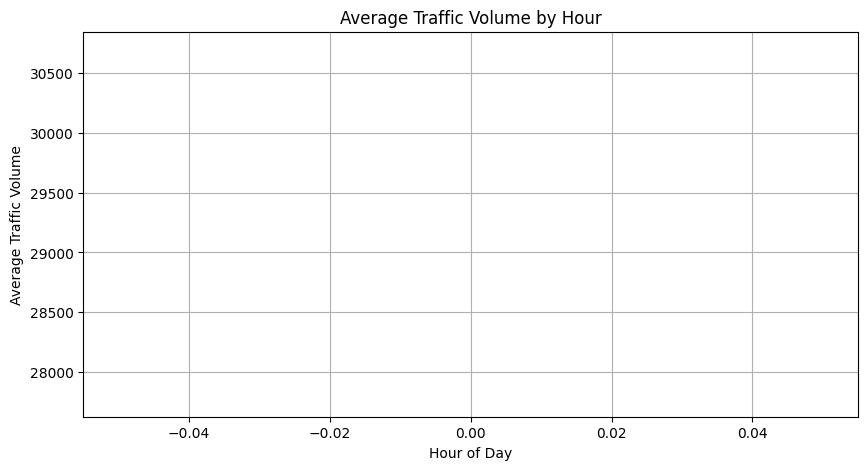

In [114]:

hourly = df.groupby('hour', as_index=False)['Traffic Volume'].mean()

plt.figure(figsize=(10,5))
plt.plot(hourly['hour'], hourly['Traffic Volume'])
plt.xlabel("Hour of Day")
plt.ylabel("Average Traffic Volume")
plt.title("Average Traffic Volume by Hour")
plt.grid(True)
plt.show()


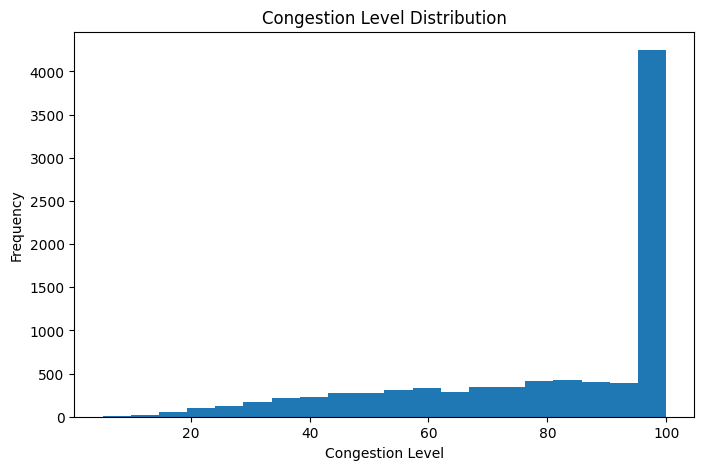

In [115]:

plt.figure(figsize=(8,5))
plt.hist(df['Congestion Level'], bins=20)
plt.xlabel("Congestion Level")
plt.ylabel("Frequency")
plt.title("Congestion Level Distribution")
plt.show()


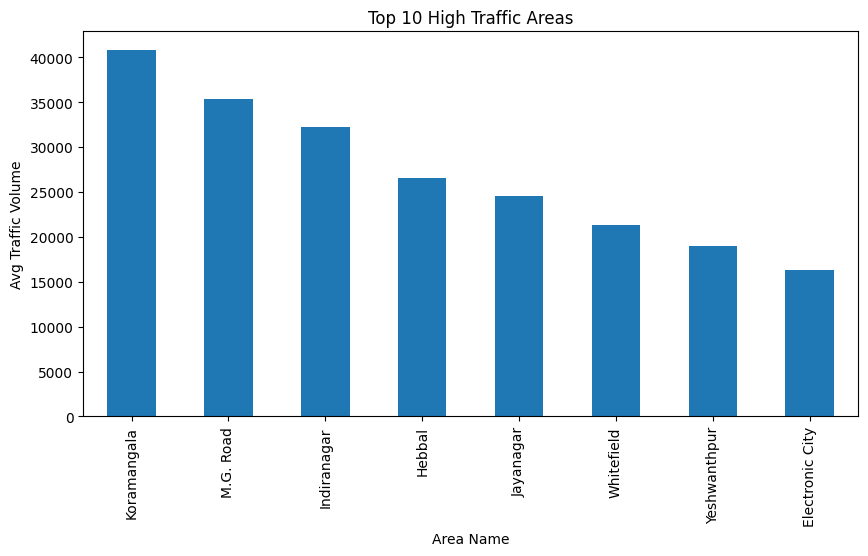

In [116]:

top_areas = (
    df.groupby('Area Name')['Traffic Volume']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_areas.plot(kind='bar', figsize=(10,5))
plt.title("Top 10 High Traffic Areas")
plt.ylabel("Avg Traffic Volume")
plt.show()


In [117]:

area_coords = {
    "Indiranagar": (12.9719, 77.6412),
    "Whitefield": (12.9698, 77.7500),
    "Koramangala": (12.9352, 77.6245),
    "Electronic City": (12.8452, 77.6600),
    "Hebbal": (13.0358, 77.5970),
    "Silk Board": (12.9177, 77.6233),
    "Yelahanka": (13.1007, 77.5963),
    "MG Road": (12.9758, 77.6096),
    "BTM Layout": (12.9166, 77.6101),
    "Marathahalli": (12.9591, 77.6974)
}

df['lat'] = df['Area Name'].map(lambda x: area_coords.get(x, (np.nan, np.nan))[0])
df['lon'] = df['Area Name'].map(lambda x: area_coords.get(x, (np.nan, np.nan))[1])

df[['Area Name', 'lat', 'lon']].head()


,Area Name,lat,lon
0,Indiranagar,12.9719,77.6412
1,Indiranagar,12.9719,77.6412
2,Whitefield,12.9698,77.7500
3,Koramangala,12.9352,77.6245
4,Koramangala,12.9352,77.6245


In [ ]:

df_ml = df.dropna(subset=['lat','lon'])
print("ML-ready shape:", df_ml.shape)
df_ml.head()


ML-ready shape: (5528, 21)


,Date,Area Name,Road/Intersection Name,Traffic Volume,Average Speed,Travel Time Index,Congestion Level,Road Capacity Utilization,Incident Reports,Environmental Impact,...,Traffic Signal Compliance,Parking Usage,Pedestrian and Cyclist Count,Weather Conditions,Roadwork and Construction Activity,hour,weekday,is_weekend,lat,lon
0,2022-01-01,Indiranagar,100 Feet Road,50590,50.230299,1.500000,100.000000,100.000000,0,151.180,...,84.044600,85.403629,111,Clear,No,0,5,1,12.9719,77.6412
1,2022-01-01,Indiranagar,CMH Road,30825,29.377125,1.500000,100.000000,100.000000,1,111.650,...,91.407038,59.983689,100,Clear,No,0,5,1,12.9719,77.6412
2,2022-01-01,Whitefield,Marathahalli Bridge,7399,54.474398,1.039069,28.347994,36.396525,0,64.798,...,61.375541,95.466020,189,Clear,No,0,5,1,12.9698,77.7500
3,2022-01-01,Koramangala,Sony World Junction,60874,43.817610,1.500000,100.000000,100.000000,1,171.748,...,75.547092,63.567452,111,Clear,No,0,5,1,12.9352,77.6245
4,2022-01-01,Koramangala,Sarjapur Road,57292,41.116763,1.500000,100.000000,100.000000,3,164.584,...,64.634762,93.155171,104,Clear,No,0,5,1,12.9352,77.6245


: 